libaraies

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns


# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

load files

In [2]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"


# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")
RI1_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv")
RI2_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv")
RI1_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv")
RI2_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv")
RI1_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv")
RI2_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv")
RI1_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv")
RI2_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv")
RI2_3_5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv")


In [3]:
ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

In [4]:
ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [5]:
ri1_boris_data = {
    "RI1_3_6": RI1_3_6_boris.copy(),
    "RI1_4_7": RI1_4_7_boris.copy(),
    "RI1_2_3": RI1_2_3_boris.copy(),
    "RI1_4_8": RI1_4_8_boris.copy(),
    "RI1_1_1": RI1_1_1_boris.copy(),
    "RI1_1_2": RI1_1_2_boris.copy(),
    "RI1_2_4": RI1_2_4_boris.copy(),
}


In [6]:
ri2_boris_data = {
    "RI2_3_6": RI2_3_6_boris.copy(),
    "RI2_4_7": RI2_4_7_boris.copy(),
    "RI2_2_3": RI2_2_3_boris.copy(),
    "RI2_4_8": RI2_4_8_boris.copy(),
    "RI2_1_1": RI2_1_1_boris.copy(),
    "RI2_1_2": RI2_1_2_boris.copy(),
    "RI2_2_4": RI2_2_4_boris.copy(),
    "RI2_3_5": RI2_3_5_boris.copy(),
}


load_clean_resp_signal function for loading and preprocessing respiration data:

Reads raw resp signal and metadata from .h5

Computes original sampling rate (fs)

Applies a low-pass filter before downsampling to avoid aliasing

Downsamples the signal to your target_rate (default 100 Hz)

Applies a bandpass filter (0.1–20 Hz) with NeuroKit to clean the signal further

Creates a time vector that matches the cleaned signal length and sampling rate

This function returns:
rsp_cleaned: the cleaned, filtered, downsampled respiratory signal array

time_vector: time points corresponding to each sample in seconds

target_rate: the sampling rate after downsampling (e.g., 100 Hz)

You can then pass these outputs to functions like:
get_percent_change_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_start, sniff_end)

get_delta_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_end)

In [7]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

In [8]:
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [9]:
resp_data = {}

for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("✅ All available signals loaded.")


Processing RI1_3_6...
Processing RI2_3_6...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
Processing RI1_1_1...
Processing RI2_1_1...
Processing RI1_1_2...
Processing RI2_1_2...
Processing RI1_2_4...
Processing RI2_2_4...
Processing RI1_3_5...
Processing RI2_3_5...
✅ All available signals loaded.


get_sniff_respiratory_rate function is good for calculating the breathing rate during a sniff bout:

It creates a mask to select the respiratory signal samples between sniff_start and sniff_end.

It uses find_peaks to detect inhalation peaks in that signal segment, with a minimum peak distance of 0.2 seconds (to avoid counting the same breath twice).

It calculates the duration of the sniff bout.

It returns the breathing rate as the number of detected peaks divided by the duration (giving rate in Hz).

A few things to watch out for:
Sampling rate consistency: Make sure the times array and the signal array are aligned and that sampling_rate matches the sampling frequency of the signal.

Peak detection threshold: You might want to tweak the distance or add a height parameter in find_peaks if you get too many or too few peaks.

Edge cases: If duration is zero or very small, it returns np.nan, which is good.



In [10]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.2)

    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate

In [11]:
def extract_agent_face_sniffs(df):
    """
    Filters BORIS dataframe for facial sniffing initiated by the social agent.
    """
    df = df.copy()
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Updated filters
    agent_mask = df['Subject'].str.lower() == 'social_agent'
    sniff_mask = df['Behavior'].str.lower() == 'facial sniffing'

    return df[agent_mask & sniff_mask]


ONE SUBJECT 3.6 WORKED

In [12]:
agent_sniffs = extract_agent_face_sniffs(RI2_3_6_boris)
print(agent_sniffs[['Subject', 'Behavior', 'Start (s)', 'Stop (s)']])


          Subject         Behavior  Start (s)  Stop (s)
12   social_agent  facial sniffing     25.600    26.100
23   social_agent  facial sniffing     68.767    69.600
36   social_agent  facial sniffing     91.900    92.267
40   social_agent  facial sniffing    153.900   154.400
41   social_agent  facial sniffing    156.233   156.567
43   social_agent  facial sniffing    195.433   195.767
46   social_agent  facial sniffing    196.167   197.500
53   social_agent  facial sniffing    218.300   219.367
59   social_agent  facial sniffing    226.433   226.900
64   social_agent  facial sniffing    234.867   235.367
67   social_agent  facial sniffing    249.733   250.567
68   social_agent  facial sniffing    257.833   258.367
70   social_agent  facial sniffing    267.400   268.933
71   social_agent  facial sniffing    269.767   270.600
75   social_agent  facial sniffing    273.367   274.200
78   social_agent  facial sniffing    282.033   283.067
79   social_agent  facial sniffing    288.200   

RUN LOOP ON ALL SUBJECTS WORKS

In [13]:
all_agent_sniffs = []

# Loop through each trial in RI2
for label, boris_df in ri2_boris_data.items():
    agent_sniffs = extract_agent_face_sniffs(boris_df)
    agent_sniffs["Trial"] = label  # Add which trial/mouse it came from
    all_agent_sniffs.append(agent_sniffs)

# Combine all the individual DataFrames into one
combined_sniffs_df = pd.concat(all_agent_sniffs, ignore_index=True)

# Preview the result
print(combined_sniffs_df[['Trial', 'Subject', 'Behavior', 'Start (s)', 'Stop (s)']].head())


     Trial       Subject         Behavior  Start (s)  Stop (s)
0  RI2_3_6  social_agent  facial sniffing     25.600    26.100
1  RI2_3_6  social_agent  facial sniffing     68.767    69.600
2  RI2_3_6  social_agent  facial sniffing     91.900    92.267
3  RI2_3_6  social_agent  facial sniffing    153.900   154.400
4  RI2_3_6  social_agent  facial sniffing    156.233   156.567


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

def calculate_percent_change_resp_rate_with_post(signal, time, sniff_start, sampling_rate=100, plot=True,
                                                 baseline_color='gray', sniff_color='orange', post_color='green',
                                                 title=None):
    """
    Calculates % change in instantaneous respiration rate (Hz) for baseline, during sniff, and post-sniff windows.

    Windows:
    - Baseline: -5s to -1s before sniff_start
    - During sniff: 0s to +0.5s after sniff_start
    - Post sniff: +0.5s to +1s after sniff_start

    Returns:
        pct_change_sniff: % change during sniff vs baseline
        pct_change_post: % change post sniff vs baseline
        baseline_mean_rate: mean baseline rate (Hz)
        sniff_mean_rate: mean during sniff rate (Hz)
        post_mean_rate: mean post sniff rate (Hz)
    """
    # Define masks for time windows
    baseline_mask = (time >= sniff_start - 5) & (time < sniff_start - 1)
    sniff_mask = (time >= sniff_start) & (time < sniff_start + 0.5)
    post_mask = (time >= sniff_start + 0.5) & (time < sniff_start + 1)

    baseline_segment = signal[baseline_mask]
    sniff_segment = signal[sniff_mask]
    post_segment = signal[post_mask]

    min_distance_samples = int(0.0833 * sampling_rate)  # ~75ms min distance between breaths

    # Detect peaks in each window
    baseline_peaks, _ = find_peaks(baseline_segment, distance=min_distance_samples)
    sniff_peaks, _ = find_peaks(sniff_segment, distance=min_distance_samples)
    post_peaks, _ = find_peaks(post_segment, distance=min_distance_samples)

    # Peak times
    baseline_peak_times = time[baseline_mask][baseline_peaks]
    sniff_peak_times = time[sniff_mask][sniff_peaks]
    post_peak_times = time[post_mask][post_peaks]

    # Calculate IBIs
    baseline_ibis = np.diff(baseline_peak_times)
    sniff_ibis = np.diff(sniff_peak_times)
    post_ibis = np.diff(post_peak_times)

    # Check enough peaks detected
    if len(baseline_ibis) == 0 or len(sniff_ibis) == 0 or len(post_ibis) == 0:
        if plot:
            print("Not enough peaks detected to calculate respiration rate change.")
        return None, None, None, None, None

    # Instantaneous respiration rates (Hz)
    baseline_rates = 1 / baseline_ibis
    sniff_rates = 1 / sniff_ibis
    post_rates = 1 / post_ibis

    baseline_mean_rate = np.mean(baseline_rates)
    sniff_mean_rate = np.mean(sniff_rates)
    post_mean_rate = np.mean(post_rates)

    pct_change_sniff = ((sniff_mean_rate - baseline_mean_rate) / baseline_mean_rate) * 100
    pct_change_post = ((post_mean_rate - baseline_mean_rate) / baseline_mean_rate) * 100

    if plot:
        plt.figure(figsize=(6, 5))
        plt.bar(['Baseline', 'During Sniff', 'Post Sniff'],
                [baseline_mean_rate, sniff_mean_rate, post_mean_rate],
                color=[baseline_color, sniff_color, post_color])
        plt.ylabel('Respiration Rate (Hz)')
        if title:
            plt.title(title)
        else:
            plt.title(f'Respiration Rate Change\nDuring: {pct_change_sniff:.2f}%, Post: {pct_change_post:.2f}%')
        plt.show()

    return pct_change_sniff, pct_change_post, baseline_mean_rate, sniff_mean_rate, post_mean_rate


In [15]:
# All agent face sniffs across conditions
all_agent_sniffs = []

# Combine both RI1 and RI2 trials
for condition_label, boris_data_dict in [("RI1", ri1_boris_data), ("RI2", ri2_boris_data)]:
    for trial_label, boris_df in boris_data_dict.items():
        agent_sniffs = extract_agent_face_sniffs(boris_df)
        agent_sniffs["Trial"] = trial_label
        all_agent_sniffs.append(agent_sniffs)

# Combine all into one DataFrame
combined_sniffs_df = pd.concat(all_agent_sniffs, ignore_index=True)

# Resp analysis
agent_sniff_results = []

for i, sniff_row in combined_sniffs_df.iterrows():
    trial = sniff_row["Trial"]
    sniff_start = sniff_row["Start (s)"]

    resp_entry = resp_data.get(trial)
    if resp_entry is None:
        print(f"Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sampling_rate = resp_entry["sampling_rate"]

    # Use updated function with baseline, sniff, post
    pct_change_sniff, pct_change_post, baseline_rate, sniff_rate, post_rate = calculate_percent_change_resp_rate_with_post(
        signal, time, sniff_start, sampling_rate=sampling_rate, plot=False
    )

    if pct_change_sniff is None:
        print(f"Not enough peaks for sniff at {sniff_start}s in {trial}, skipping...")
        continue

    agent_sniff_results.append({
        "Trial": trial,
        "Sniff Start": sniff_start,
        "Percent Change Sniff": pct_change_sniff,
        "Percent Change Post": pct_change_post,
        "Baseline Rate": baseline_rate,
        "Sniff Rate": sniff_rate,
        "Post Rate": post_rate
    })

# Final combined DataFrame
agent_sniff_df = pd.DataFrame(agent_sniff_results)



Not enough peaks for sniff at 153.9s in RI2_3_6, skipping...
Not enough peaks for sniff at 224.267s in RI2_4_8, skipping...
Not enough peaks for sniff at 488.333s in RI2_4_8, skipping...
Not enough peaks for sniff at 496.633s in RI2_4_8, skipping...


In [16]:
agent_sniff_df

,Trial,Sniff Start,Percent Change Sniff,Percent Change Post,Baseline Rate,Sniff Rate,Post Rate
0,RI1_3_6,12.069,40.676642,39.001920,8.293251,11.666667,11.527778
1,RI1_3_6,86.207,10.004107,-8.259123,9.343085,10.277778,8.571429
2,RI1_3_6,88.034,0.916251,10.952121,9.058416,9.141414,10.050505
3,RI1_3_6,107.724,-11.677579,12.284897,10.064136,8.888889,11.300505
4,RI1_3_6,183.724,10.348498,14.323186,8.585148,9.473582,9.814815
5,RI1_3_6,200.517,-30.232249,-10.727799,8.728594,6.089744,7.792208
6,RI1_3_6,217.172,21.402426,-47.569405,8.292536,10.067340,4.347826
7,RI1_3_6,229.897,5.411681,-20.110195,8.911668,9.393939,7.119514
8,RI1_3_6,243.793,-39.789755,16.248323,8.344942,5.024510,9.700855
9,RI1_3_6,337.172,-0.615095,-59.394167,8.209001,8.158508,3.333333


C:\Users\sjs93\AppData\Local\Temp\ipykernel_29832\3075889467.py:46: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(


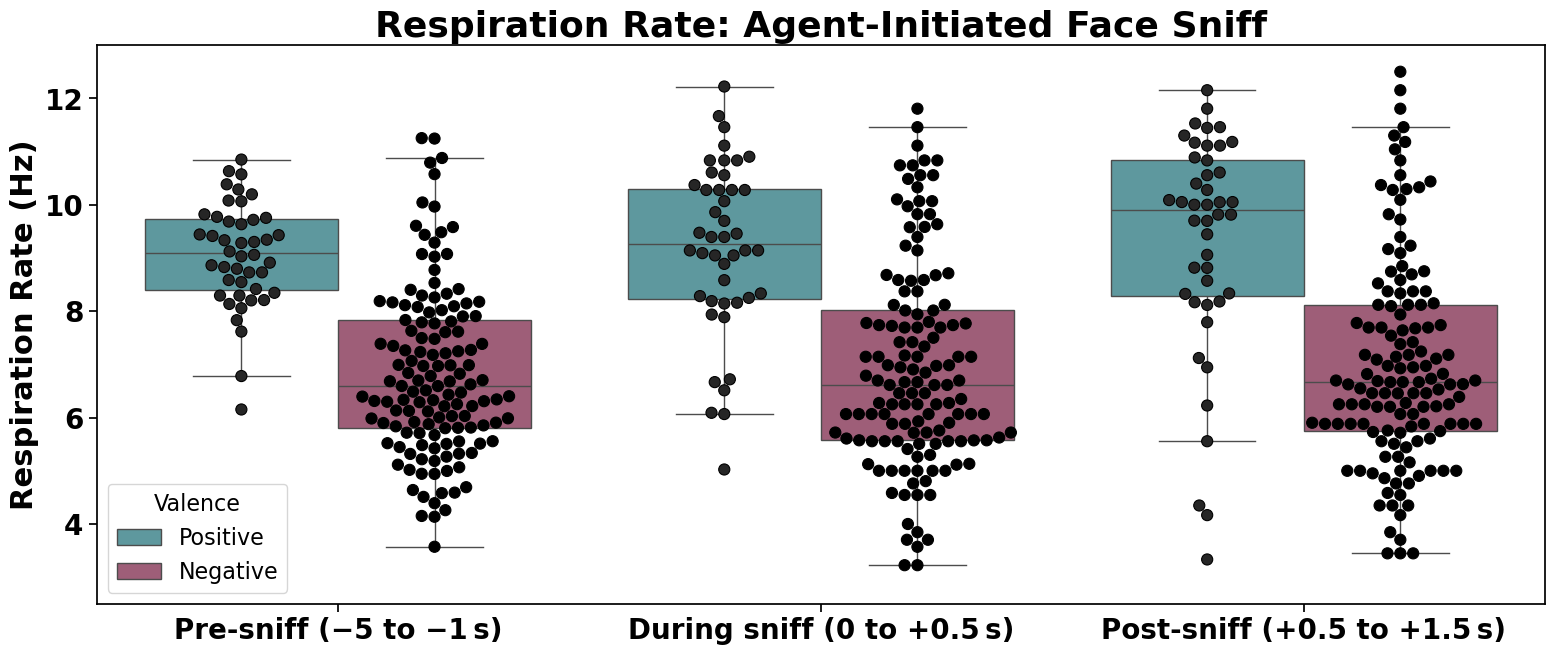

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add Valence labels
agent_sniff_df["Valence"] = agent_sniff_df["Trial"].apply(
    lambda x: "Positive" if "RI1" in x else ("Negative" if "RI2" in x else "Unknown")
)
agent_sniff_df = agent_sniff_df[agent_sniff_df["Valence"] != "Unknown"]

# Melt dataframe to long format
plot_df = agent_sniff_df.melt(
    id_vars=["Trial", "Valence"],
    value_vars=["Baseline Rate", "Sniff Rate", "Post Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

# Rename conditions for clarity
plot_df["Condition"] = plot_df["Condition"].replace({
    "Baseline Rate": "Pre-sniff (−5 to −1 s)",
    "Sniff Rate": "During sniff (0 to +0.5 s)",
    "Post Rate": "Post-sniff (+0.5 to +1.5 s)"
})

# Set custom colors
custom_palette = {
    "Positive": (83/255, 161/255, 169/255),   # RI1
    "Negative": (169/255, 83/255, 118/255)    # RI2
}

# === Plotting ===
plt.figure(figsize=(16, 7))
sns.set_context("notebook", font_scale=1.8)

# Boxplot
sns.boxplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    palette=custom_palette,
    fliersize=0
)

# Swarmplot (data points)
sns.swarmplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    dodge=True,
    color='black',
    edgecolor='black',
    alpha=1,
    size=8,
    linewidth=0.8,
    legend=False
)

# Labels and styling
plt.title("Respiration Rate: Agent-Initiated Face Sniff", fontsize=26, weight='bold')
plt.ylabel("Respiration Rate (Hz)", fontsize=22, weight='bold')
plt.xlabel('')
plt.xticks(fontsize=20, weight='bold')
plt.yticks(ticks=[4, 6, 8, 10, 12],fontsize=20, weight='bold')
plt.ylim(2.5, 13)

plt.legend(title='Valence', fontsize=16, title_fontsize=16, loc='lower left', bbox_to_anchor=(0, 0))
plt.tight_layout()
plt.show()


In [18]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# Step 1: Filter out unknowns
df = agent_sniff_df.copy()
df = df[df["Valence"].isin(["Positive", "Negative"])]

# Step 2: Drop any rows with missing respiration values
df = df.dropna(subset=["Baseline Rate", "Sniff Rate", "Post Rate"])

# Step 3: Wilcoxon signed-rank tests
stat_1, p_1 = wilcoxon(df["Baseline Rate"], df["Sniff Rate"])
stat_2, p_2 = wilcoxon(df["Baseline Rate"], df["Post Rate"])

# Step 4: Apply multiple comparisons correction
raw_pvals = [p_1, p_2]
reject_fdr, pvals_fdr, _, _ = multipletests(raw_pvals, method='fdr_bh')
reject_bonf, pvals_bonf, _, _ = multipletests(raw_pvals, method='bonferroni')

# Step 5: Print results
print("📊 Wilcoxon Signed-Rank Tests (Agent-Initiated Face Sniff):\n")

print("Baseline vs During Sniff:")
print(f"  Raw p = {p_1:.4f}")
print(f"  FDR-corrected p = {pvals_fdr[0]:.4f}")
print(f"  Bonferroni-corrected p = {pvals_bonf[0]:.4f}\n")

print("Baseline vs Post-sniff:")
print(f"  Raw p = {p_2:.4f}")
print(f"  FDR-corrected p = {pvals_fdr[1]:.4f}")
print(f"  Bonferroni-corrected p = {pvals_bonf[1]:.4f}")


📊 Wilcoxon Signed-Rank Tests (Agent-Initiated Face Sniff):

Baseline vs During Sniff:
  Raw p = 0.3618
  FDR-corrected p = 0.4635
  Bonferroni-corrected p = 0.7237

Baseline vs Post-sniff:
  Raw p = 0.4635
  FDR-corrected p = 0.4635
  Bonferroni-corrected p = 0.9269


In [19]:
from scipy.stats import mannwhitneyu

# Compare valence groups for each time window
pre_pos = df[df["Valence"] == "Positive"]["Baseline Rate"]
pre_neg = df[df["Valence"] == "Negative"]["Baseline Rate"]
during_pos = df[df["Valence"] == "Positive"]["Sniff Rate"]
during_neg = df[df["Valence"] == "Negative"]["Sniff Rate"]
post_pos = df[df["Valence"] == "Positive"]["Post Rate"]
post_neg = df[df["Valence"] == "Negative"]["Post Rate"]

# Perform tests
p_pre = mannwhitneyu(pre_pos, pre_neg, alternative="two-sided")[1]
p_during = mannwhitneyu(during_pos, during_neg, alternative="two-sided")[1]
p_post = mannwhitneyu(post_pos, post_neg, alternative="two-sided")[1]

# Correct for multiple comparisons
raw_pvals = [p_pre, p_during, p_post]
_, fdr_pvals, _, _ = multipletests(raw_pvals, method="fdr_bh")
_, bonf_pvals, _, _ = multipletests(raw_pvals, method="bonferroni")

# Report
print("📊 Mann–Whitney U Tests (Negative vs Positive):")
print(f"Pre-sniff: Raw p = {p_pre:.4f}, FDR = {fdr_pvals[0]:.4f}, Bonferroni = {bonf_pvals[0]:.4f}")
print(f"During sniff: Raw p = {p_during:.4f}, FDR = {fdr_pvals[1]:.4f}, Bonferroni = {bonf_pvals[1]:.4f}")
print(f"Post-sniff: Raw p = {p_post:.4f}, FDR = {fdr_pvals[2]:.4f}, Bonferroni = {bonf_pvals[2]:.4f}")


📊 Mann–Whitney U Tests (Negative vs Positive):
Pre-sniff: Raw p = 0.0000, FDR = 0.0000, Bonferroni = 0.0000
During sniff: Raw p = 0.0000, FDR = 0.0000, Bonferroni = 0.0000
Post-sniff: Raw p = 0.0000, FDR = 0.0000, Bonferroni = 0.0000
